In [43]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Flatten, Dense, InputLayer
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [45]:
df = pd.read_csv(r"G:\Coding Languages\Artificial Intelligence\Excel and Csv\Telco Customer Churn.csv")
GenderLE = LabelEncoder()
SeniorCitizenLE = LabelEncoder()
PartnerLE = LabelEncoder()
DependentsLE = LabelEncoder()
PhoneServiceLE = LabelEncoder()
InternetServiceLE = LabelEncoder()
OnlineSecurityLE = LabelEncoder()
OnlineBackupLE = LabelEncoder()
DeviceProtectionLE = LabelEncoder()
TechSupportLE = LabelEncoder()
StreamingTVLE = LabelEncoder()
StreamingMoviesLE = LabelEncoder()
ContractLE = LabelEncoder()
PaperlessBillingLE = LabelEncoder()
PaymentMethodLE = LabelEncoder()
ChurnLE = LabelEncoder()
scaler = StandardScaler()
df2 = df.copy()

In [46]:
df2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,0,0,2,0,0,0,0,0,1,2,29.85,0
1,1,0,0,0,34,1,0,2,0,2,0,0,0,1,0,3,56.95,0
2,1,0,0,0,2,1,0,2,2,0,0,0,0,0,1,3,53.85,1
3,1,0,0,0,45,0,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,0,0,2,1,1,0,0,0,0,0,0,0,1,2,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,0,2,0,2,2,2,2,1,1,3,84.80,0
7039,0,0,1,1,72,1,1,0,2,2,0,2,2,1,1,1,103.20,0
7040,0,0,1,1,11,0,0,2,0,0,0,0,0,0,1,2,29.60,0
7041,1,1,1,0,4,1,1,0,0,0,0,0,0,0,1,3,74.40,1


In [15]:
df2 = df2.drop(columns = ['customerID','MultipleLines','TotalCharges'])

In [16]:
df2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No
7039,Female,0,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No
7040,Female,0,Yes,Yes,11,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No
7041,Male,1,Yes,No,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes


In [17]:
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Churn'],
      dtype='object')

In [19]:
df2['gender'] = GenderLE.fit_transform(df2['gender'])
df2['Partner'] = PartnerLE.fit_transform(df2['Partner'])
df2['Dependents'] = DependentsLE.fit_transform(df2['Dependents'])
df2['PhoneService'] = PhoneServiceLE.fit_transform(df2['PhoneService'])
df2['InternetService'] = InternetServiceLE.fit_transform(df2['InternetService'])
df2['OnlineSecurity'] = OnlineSecurityLE.fit_transform(df2['OnlineSecurity'])
df2['OnlineBackup'] = OnlineBackupLE.fit_transform(df2['OnlineBackup'])
df2['DeviceProtection'] = DeviceProtectionLE.fit_transform(df2['DeviceProtection'])
df2['TechSupport'] = TechSupportLE.fit_transform(df2['TechSupport'])
df2['StreamingTV'] = StreamingTVLE.fit_transform(df2['StreamingTV'])
df2['StreamingMovies'] = StreamingMoviesLE.fit_transform(df2['StreamingMovies'])
df2['Contract'] = ContractLE.fit_transform(df2['Contract'])
df2['PaperlessBilling'] = PaperlessBillingLE.fit_transform(df2['PaperlessBilling'])
df2['PaymentMethod'] = PaymentMethodLE.fit_transform(df2['PaymentMethod'])
df2['Churn'] = ChurnLE.fit_transform(df2['Churn'])

In [20]:
df2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,0,0,2,0,0,0,0,0,1,2,29.85,0
1,1,0,0,0,34,1,0,2,0,2,0,0,0,1,0,3,56.95,0
2,1,0,0,0,2,1,0,2,2,0,0,0,0,0,1,3,53.85,1
3,1,0,0,0,45,0,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,0,0,2,1,1,0,0,0,0,0,0,0,1,2,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,0,2,0,2,2,2,2,1,1,3,84.80,0
7039,0,0,1,1,72,1,1,0,2,2,0,2,2,1,1,1,103.20,0
7040,0,0,1,1,11,0,0,2,0,0,0,0,0,0,1,2,29.60,0
7041,1,1,1,0,4,1,1,0,0,0,0,0,0,0,1,3,74.40,1


In [22]:
x = df2.drop(columns = 'Churn')
y = df2['Churn']

<Axes: xlabel='DeviceProtection', ylabel='count'>

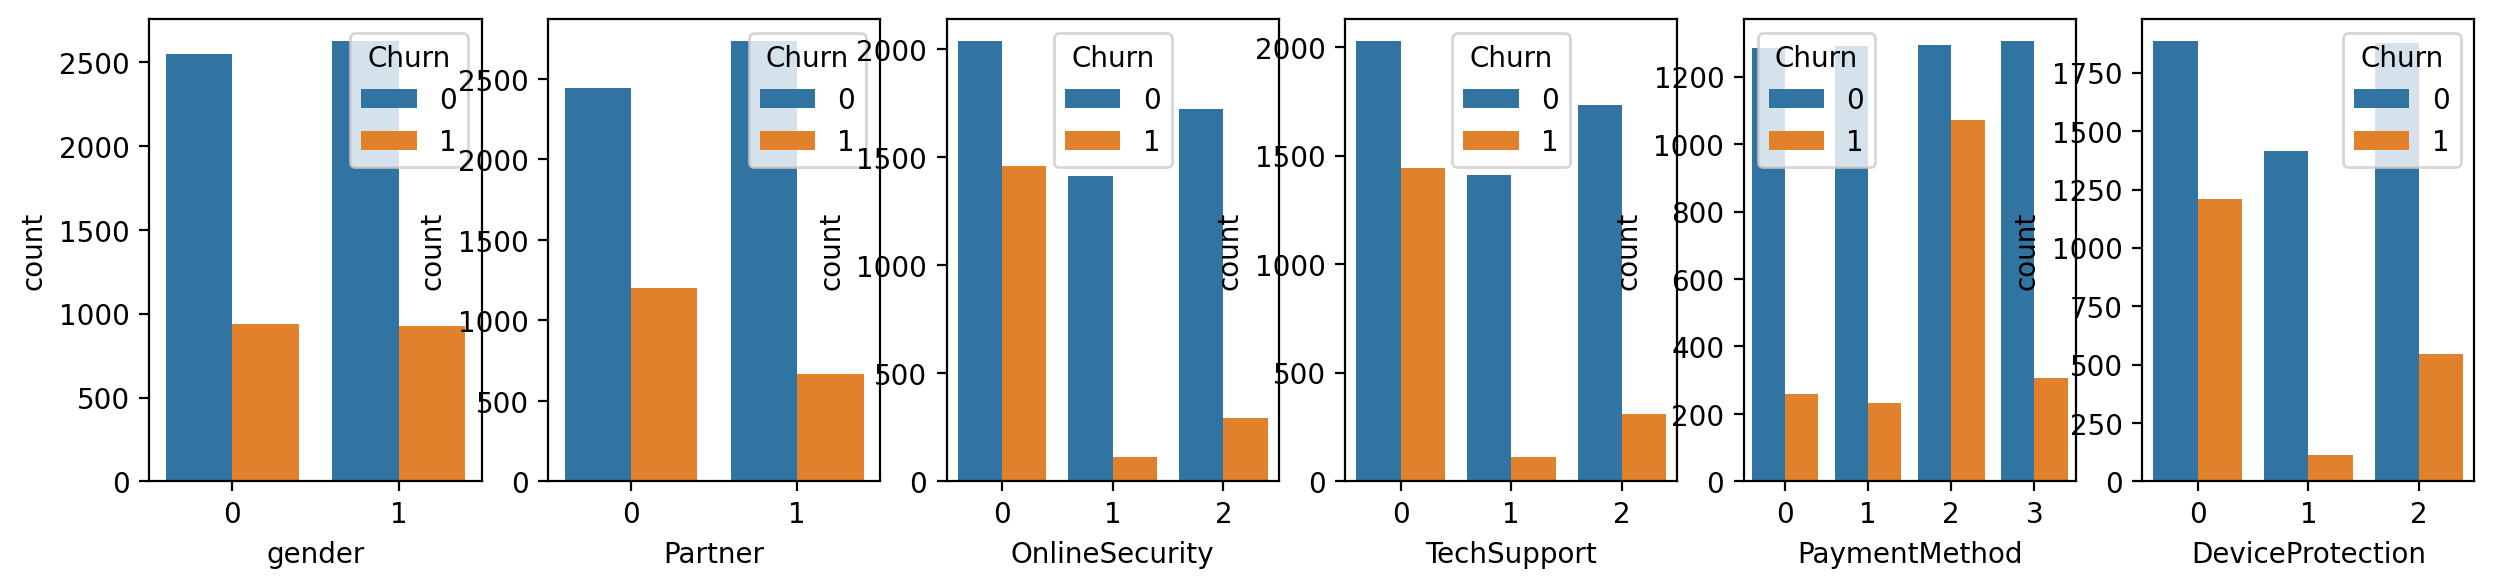

In [40]:
mp.rcParams['figure.figsize'] = (15,3)
mp.rcParams['figure.dpi'] = 200
fig,ax = mp.subplots(1,6)
# sns.countplot(x = 'gender',data = x,ax = ax[0],hue = y)
sns.countplot(x = 'gender',data = x,ax = ax[0],hue = y)
sns.countplot(x = 'Partner',data = x,ax = ax[1],hue = y)
sns.countplot(x = 'OnlineSecurity',data = x,ax = ax[2],hue = y)
sns.countplot(x = 'TechSupport',data = x,ax = ax[3],hue = y)
sns.countplot(x = 'PaymentMethod',data = x,ax = ax[4],hue = y)
sns.countplot(x = 'DeviceProtection',data = x,ax = ax[5],hue = y)

In [38]:
mp.tight_layout()

<Figure size 3000x600 with 0 Axes>

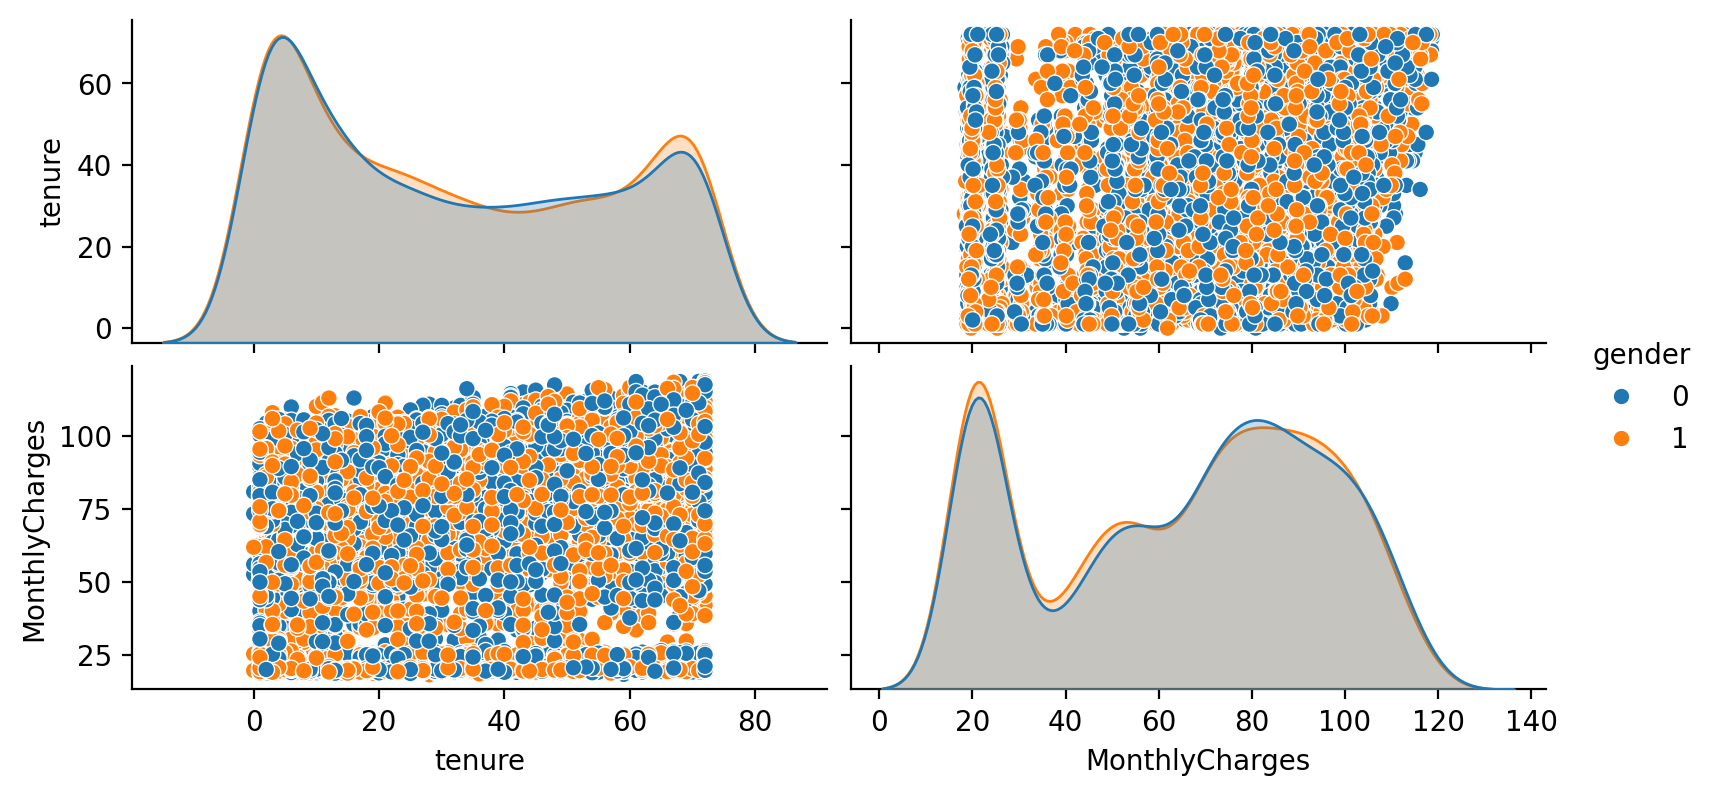

In [42]:
sns.pairplot(df2, vars=['tenure', 'MonthlyCharges'], height=2, aspect=2, hue='gender')

In [44]:
xtrain,xtest,ytrain,ytest = train_test_split(x, y, random_state = 70, test_size = 0.3, stratify = y)

In [47]:
xtrainscaled = scaler.fit_transform(xtrain)
xtestscaled = scaler.fit_transform(xtest)

In [49]:
IPShape = xtrainscaled.shape

In [52]:
ClassWeight = y.value_counts().to_dict()

In [53]:
IPShape,ClassWeight

((4930, 17), {0: 5174, 1: 1869})

In [55]:
TotalSample = sum(ClassWeight.values())
ClassWeight = [TotalSample/(len(ClassWeight)*ClassWeight[0]),
              TotalSample/len(ClassWeight)*ClassWeight[1]]

In [56]:
ClassWeight

[0.6806146115191342, 6581683.5]

In [59]:
Model = Sequential()
Model.add(InputLayer(IPShape))
Model.add(Dense(128,activation = 'relu'))
Model.add(Dense(128,activation = 'relu'))
Model.add(Dense(1,activation = 'sigmoid'))

In [61]:
Model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4930, 128)           │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4930, 128)           │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4930, 1)             │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,945 (74.00 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
Model.compile(optimizer = Adam(learning_rate = 0.001,loss='binary_crossentropy',metrics = ['accuracy']))

ValueError: Argument(s) not recognized: {'loss': 'binary_crossentropy', 'metrics': ['accuracy']}